# 🤖 Modèle de Recommandation — SVD
**Algorithme :** Décomposition en Valeurs Singulières (SVD) via scikit-learn

**Objectif :** Prédire la note qu'un utilisateur donnerait à un film non encore vu.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pickle, math

plt.style.use('dark_background')
print('✅ Librairies importées !')

✅ Librairies importées !


In [2]:
# Chargement des données
ratings = pd.read_csv('../data/ratings.csv')
movies  = pd.read_csv('../data/movies.csv')

print(f'✅ {len(ratings):,} notes chargées')
print(f'✅ {len(movies):,} films chargés')
print(f'✅ {ratings["userId"].nunique()} utilisateurs')

✅ 100,836 notes chargées
✅ 9,742 films chargés
✅ 610 utilisateurs


## 1. Construction de la matrice Utilisateur × Film

In [3]:
# Matrice pivot : lignes = utilisateurs, colonnes = films
matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

print(f'Dimensions de la matrice : {matrix.shape}')
print(f'Densité : {matrix.notna().sum().sum() / matrix.size * 100:.2f}%')
print(f'Sparsité : {matrix.isna().sum().sum() / matrix.size * 100:.2f}%')
matrix.head(3)

Dimensions de la matrice : (610, 9724)
Densité : 1.70%
Sparsité : 98.30%


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Centrage des notes (Mean-Centering)

In [4]:
# Centrer les notes par utilisateur pour supprimer le biais
user_means = matrix.mean(axis=1)
matrix_centered = matrix.sub(user_means, axis=0).fillna(0)

print('Note moyenne par utilisateur (5 premiers):')
print(user_means.head())
print(f'\nAprès centrage — moyenne globale : {matrix_centered.values.mean():.6f} (≈ 0)')

Note moyenne par utilisateur (5 premiers):
userId
1    4.366379
2    3.948276
3    2.435897
4    3.555556
5    3.636364
dtype: float64

Après centrage — moyenne globale : -0.000000 (≈ 0)


## 3. Décomposition SVD

In [5]:
# SVD avec 50 facteurs latents
svd = TruncatedSVD(n_components=50, random_state=42)
U = svd.fit_transform(matrix_centered)
Vt = svd.components_

print(f'Matrice U (utilisateurs × facteurs) : {U.shape}')
print(f'Matrice Vt (facteurs × films)       : {Vt.shape}')
print(f'Variance expliquée : {svd.explained_variance_ratio_.sum()*100:.2f}%')

Matrice U (utilisateurs × facteurs) : (610, 50)
Matrice Vt (facteurs × films)       : (50, 9724)
Variance expliquée : 48.88%


## 4. Reconstruction et évaluation

In [6]:
# Matrice prédite
pred_centered = np.dot(U, Vt)
pred_df = pd.DataFrame(pred_centered, index=matrix.index, columns=matrix.columns)
pred_df = pred_df.add(user_means, axis=0).clip(0.5, 5.0)

# Split train/test
train_r, test_r = train_test_split(ratings, test_size=0.2, random_state=42)

# Évaluation
preds, actuals = [], []
for _, row in test_r.iterrows():
    uid, mid, actual = row['userId'], row['movieId'], row['rating']
    if uid in pred_df.index and mid in pred_df.columns:
        preds.append(pred_df.loc[uid, mid])
        actuals.append(actual)

rmse = math.sqrt(mean_squared_error(actuals, preds))
mae  = np.mean(np.abs(np.array(actuals) - np.array(preds)))

print('=== Résultats du modèle ===')
print(f'✅ RMSE : {rmse:.4f}')
print(f'✅ MAE  : {mae:.4f}')

=== Résultats du modèle ===
✅ RMSE : 0.6217
✅ MAE  : 0.3998


## 5. Visualisation des erreurs

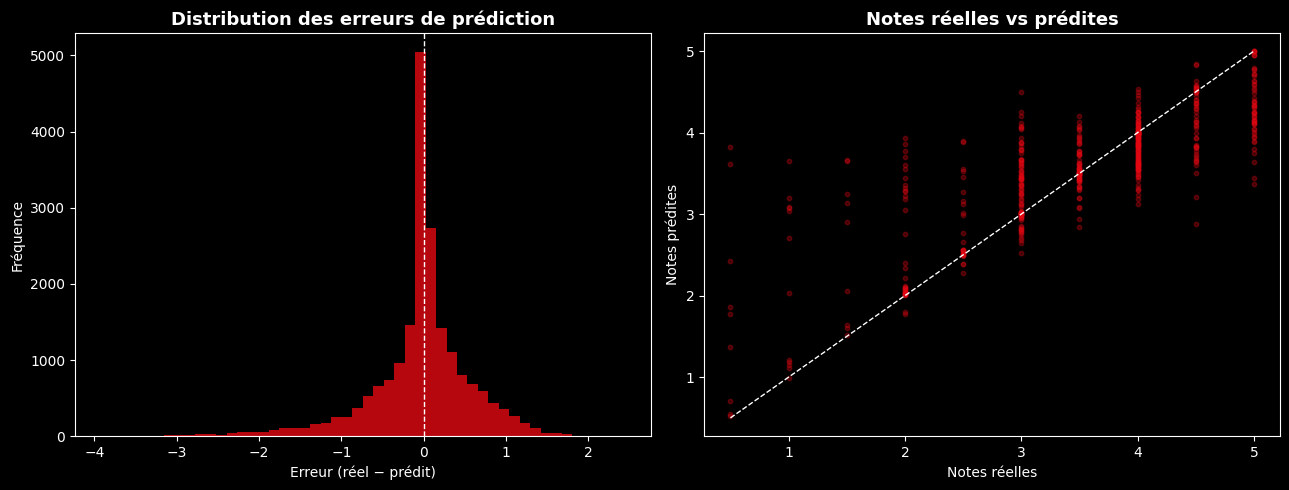

In [7]:
errors = np.array(actuals) - np.array(preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(errors, bins=50, color='#E50914', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='white', linewidth=1, linestyle='--')
axes[0].set_title('Distribution des erreurs de prédiction', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Erreur (réel − prédit)')
axes[0].set_ylabel('Fréquence')

axes[1].scatter(actuals[:500], preds[:500], alpha=0.3, color='#E50914', s=10)
axes[1].plot([0.5,5],[0.5,5], 'w--', linewidth=1)
axes[1].set_xlabel('Notes réelles')
axes[1].set_ylabel('Notes prédites')
axes[1].set_title('Notes réelles vs prédites', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/evaluation_modele.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Test — Recommandations pour un utilisateur

In [8]:
def recommander(user_id, n=10):
    """Recommande n films non vus à un utilisateur."""
    films_vus = ratings[ratings['userId']==user_id]['movieId'].tolist()
    films_non_vus = [m for m in pred_df.columns if m not in films_vus]
    
    scores = pred_df.loc[user_id, films_non_vus].sort_values(ascending=False).head(n)
    resultat = movies[movies['movieId'].isin(scores.index)].copy()
    resultat['score_prédit'] = resultat['movieId'].map(scores)
    return resultat[['title','genres','score_prédit']].sort_values('score_prédit', ascending=False)

print('🎬 Recommandations pour l\'utilisateur #1 :')
print(recommander(1, 10).to_string(index=False))

🎬 Recommandations pour l'utilisateur #1 :
                                                    title                                              genres  score_prédit
                                Dead Poets Society (1989)                                               Drama      4.608672
                                            Snatch (2000)                               Comedy|Crime|Thriller      4.587101
                               Sound of Music, The (1965)                                     Musical|Romance      4.576907
                               Little Mermaid, The (1989)           Animation|Children|Comedy|Musical|Romance      4.574988
                                  Sixth Sense, The (1999)                                Drama|Horror|Mystery      4.574478
                                       Rear Window (1954)                                    Mystery|Thriller      4.572992
Lord of the Rings: The Fellowship of the Ring, The (2001)                                 

## 7. Sauvegarde du modèle

In [9]:
model_data = {
    'svd'              : svd,
    'U'                : U,
    'Vt'               : Vt,
    'matrix'           : matrix,
    'matrix_centered'  : matrix_centered,
    'pred_df'          : pred_df,
    'user_means'       : user_means,
    'movies'           : movies,
    'ratings'          : ratings,
    'rmse'             : rmse,
    'mae'              : mae
}

with open('../models/svd_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('✅ Modèle sauvegardé dans models/svd_model.pkl')
print(f'   RMSE final : {rmse:.4f}')
print(f'   MAE final  : {mae:.4f}')

✅ Modèle sauvegardé dans models/svd_model.pkl
   RMSE final : 0.6217
   MAE final  : 0.3998
